# TMDB Movie Dataset — Data Analysis

1. Load and inspect the data
2. Clean the data (missing values, duplicates, data types)
3. Answer simple business/analysis questions with tables and charts
4. Wrap up with a short summary of findings



## 1. Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look a bit nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the dataset
df = pd.read_excel("tmdb__1_.xlsx")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (10869, 21)


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397.0,tt0369610,32.985763,150000000.0,1.513529e+09,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124.0,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,2015-09-06 00:00:00,5562.0,6.5,2015.0,1.379999e+08,1.392446e+09
1,76341.0,tt1392190,28.419936,150000000.0,3.784364e+08,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120.0,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185.0,7.1,2015.0,1.379999e+08,3.481613e+08
2,262500.0,tt2908446,13.112507,110000000.0,2.952382e+08,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119.0,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480.0,6.3,2015.0,1.012000e+08,2.716190e+08
3,140607.0,tt2488496,11.173104,200000000.0,2.068178e+09,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136.0,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292.0,7.5,2015.0,1.839999e+08,1.902723e+09
4,168259.0,tt2820852,9.335014,190000000.0,1.506249e+09,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137.0,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,2015-01-04 00:00:00,2947.0,7.3,2015.0,1.747999e+08,1.385749e+09


### Quick look at the data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10869 entries, 0 to 10868
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  float64
 1   imdb_id               10856 non-null  str    
 2   popularity            10867 non-null  float64
 3   budget                10866 non-null  float64
 4   revenue               10866 non-null  float64
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  float64
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

In [ ]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10867.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,1.646289,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,104.233908,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207591,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383880,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713994,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,10866.000000,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


## 2. Data Cleaning

Before analysing, we clean the data so our answers aren't skewed by bad values. Steps:
- Drop columns we won't use for analysis (like `homepage`, `overview`, `tagline`)
- Remove duplicate rows
- Handle missing values in important columns
- Fix data types (e.g. `release_date` to a real date)
- Deal with `budget` and `revenue` values that are `0` (these usually mean "unknown", not "free movie")

In [ ]:
# Check missing values before cleaning
df.isnull().sum()

id                         3
imdb_id                   13
popularity                 2
budget                     3
revenue                    3
original_title             3
cast                      79
homepage                7933
director                  47
tagline                 2827
keywords                1496
overview                   7
runtime                    3
genres                    26
production_companies    1033
release_date               3
vote_count                 3
vote_average               3
release_year               3
budget_adj                 3
revenue_adj                3
dtype: int64

In [ ]:
# Drop columns that aren't useful for this analysis
cols_to_drop = ['homepage', 'tagline', 'overview', 'keywords', 'imdb_id', 'production_companies']
df = df.drop(columns=cols_to_drop)

# Remove duplicate rows
df = df.drop_duplicates()

# Drop rows missing an id (a handful of blank/junk rows)
df = df.dropna(subset=['id'])

# Convert release_date to a proper datetime, and release_year to a whole number
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_year'].astype('Int64')

# Fill missing text fields with 'Unknown' so groupby/value_counts work cleanly
for col in ['director', 'cast', 'genres']:
    df[col] = df[col].fillna('Unknown')

print("Shape after cleaning:", df.shape)
df.isnull().sum()

Shape after cleaning: (10865, 15)


id                0
popularity        0
budget            0
revenue           0
original_title    0
cast              0
director          0
runtime           0
genres            0
release_date      0
vote_count        0
vote_average      0
release_year      0
budget_adj        0
revenue_adj       0
dtype: int64

In [ ]:
# budget and revenue of 0 mean "not recorded", not that the movie was free.
# We keep these rows in the main dataframe, but create a separate dataframe
# for any question that involves money, using only movies with real budget/revenue data.
money_df = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

# Add a profit column (revenue - budget)
money_df['profit'] = money_df['revenue'] - money_df['budget']

print("Movies with usable budget & revenue data:", money_df.shape[0])
money_df[['original_title', 'budget', 'revenue', 'profit']].head()

Movies with usable budget & revenue data: 3854


,original_title,budget,revenue,profit
0,Jurassic World,150000000.0,1.513529e+09,1.363529e+09
1,Mad Max: Fury Road,150000000.0,3.784364e+08,2.284364e+08
2,Insurgent,110000000.0,2.952382e+08,1.852382e+08
3,Star Wars: The Force Awakens,200000000.0,2.068178e+09,1.868178e+09
4,Furious 7,190000000.0,1.506249e+09,1.316249e+09


## 3. Preparing Genres for Analysis

Each movie can have multiple genres separated by `|` (e.g. `Action|Adventure`).
To analyse genres properly, we split them into separate rows.

In [ ]:
genres_df = df.copy()
genres_df['genres'] = genres_df['genres'].str.split('|')
genres_df = genres_df.explode('genres')

print("Rows after splitting genres:", genres_df.shape[0])
genres_df[['original_title', 'genres']].head()

Rows after splitting genres: 26978


,original_title,genres
0,Jurassic World,Action
0,Jurassic World,Adventure
0,Jurassic World,Science Fiction
0,Jurassic World,Thriller
1,Mad Max: Fury Road,Action


## 4. Analysis — Answering Common Questions

### Q1: Which movies were the most popular?

In [ ]:
top_popular = df.sort_values('popularity', ascending=False).head(10)
top_popular[['original_title', 'popularity', 'release_year']]

,original_title,popularity,release_year
0,Jurassic World,32.985763,2015
1,Mad Max: Fury Road,28.419936,2015
629,Interstellar,24.949134,2014
630,Guardians of the Galaxy,14.311205,2014
2,Insurgent,13.112507,2015
631,Captain America: The Winter Soldier,12.971027,2014
1329,Star Wars,12.037933,1977
632,John Wick,11.422751,2014
3,Star Wars: The Force Awakens,11.173104,2015
633,The Hunger Games: Mockingjay - Part 1,10.739009,2014


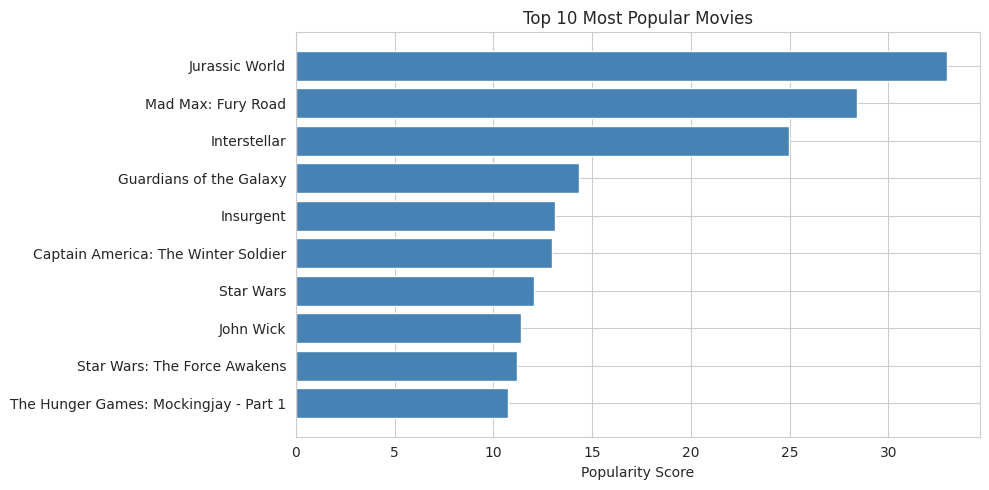

In [ ]:
plt.barh(top_popular['original_title'], top_popular['popularity'], color='steelblue')
plt.xlabel('Popularity Score')
plt.title('Top 10 Most Popular Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q2: Which movies earned the most revenue?

In [ ]:
top_revenue = money_df.sort_values('revenue', ascending=False).head(10)
top_revenue[['original_title', 'budget', 'revenue', 'profit']]

,original_title,budget,revenue,profit
1386,Avatar,237000000.0,2.781506e+09,2.544506e+09
3,Star Wars: The Force Awakens,200000000.0,2.068178e+09,1.868178e+09
5231,Titanic,200000000.0,1.845034e+09,1.645034e+09
4361,The Avengers,220000000.0,1.519558e+09,1.299558e+09
0,Jurassic World,150000000.0,1.513529e+09,1.363529e+09
4,Furious 7,190000000.0,1.506249e+09,1.316249e+09
14,Avengers: Age of Ultron,280000000.0,1.405036e+09,1.125036e+09
3374,Harry Potter and the Deathly Hallows: Part 2,125000000.0,1.327818e+09,1.202818e+09
5422,Frozen,150000000.0,1.274219e+09,1.124219e+09
5425,Iron Man 3,200000000.0,1.215440e+09,1.015440e+09


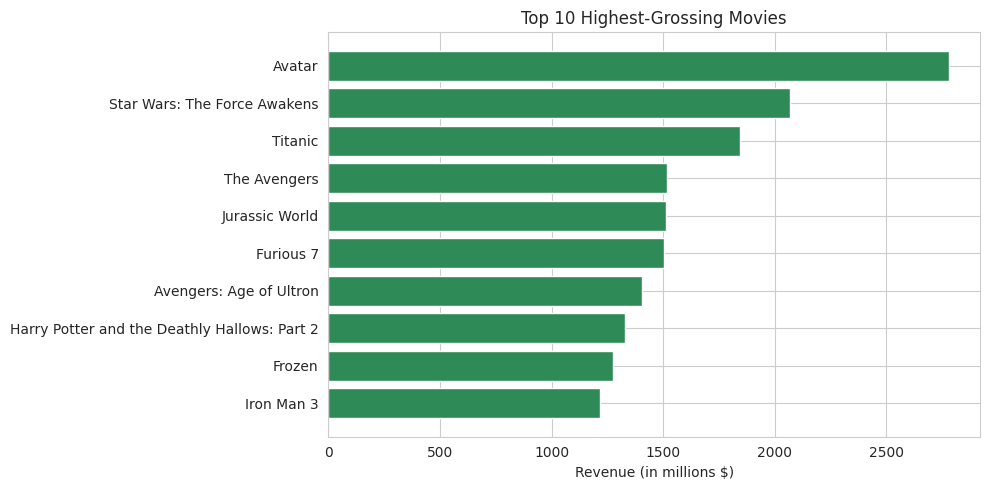

In [ ]:
plt.barh(top_revenue['original_title'], top_revenue['revenue'] / 1e6, color='seagreen')
plt.xlabel('Revenue (in millions $)')
plt.title('Top 10 Highest-Grossing Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q3: Which movies were the most profitable?

In [ ]:
top_profit = money_df.sort_values('profit', ascending=False).head(10)
top_profit[['original_title', 'budget', 'revenue', 'profit']]

,original_title,budget,revenue,profit
1386,Avatar,237000000.0,2.781506e+09,2.544506e+09
3,Star Wars: The Force Awakens,200000000.0,2.068178e+09,1.868178e+09
5231,Titanic,200000000.0,1.845034e+09,1.645034e+09
0,Jurassic World,150000000.0,1.513529e+09,1.363529e+09
4,Furious 7,190000000.0,1.506249e+09,1.316249e+09
4361,The Avengers,220000000.0,1.519558e+09,1.299558e+09
3374,Harry Potter and the Deathly Hallows: Part 2,125000000.0,1.327818e+09,1.202818e+09
14,Avengers: Age of Ultron,280000000.0,1.405036e+09,1.125036e+09
5422,Frozen,150000000.0,1.274219e+09,1.124219e+09
8094,The Net,22000000.0,1.106280e+09,1.084280e+09


### Q4: Does spending a bigger budget lead to more revenue?

We check this with a scatter plot and a correlation score.
A correlation close to `1` means a strong positive relationship; close to `0` means little to no relationship.

Correlation between budget and revenue: 0.69


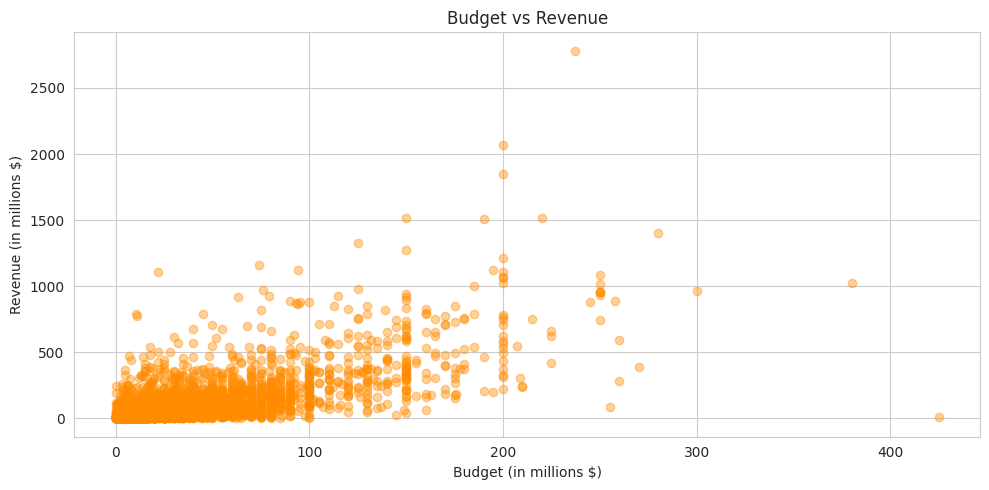

In [ ]:
correlation = money_df['budget'].corr(money_df['revenue'])
print(f"Correlation between budget and revenue: {correlation:.2f}")

plt.scatter(money_df['budget'] / 1e6, money_df['revenue'] / 1e6, alpha=0.4, color='darkorange')
plt.xlabel('Budget (in millions $)')
plt.ylabel('Revenue (in millions $)')
plt.title('Budget vs Revenue')
plt.tight_layout()
plt.show()

### Q5: What are the most common movie genres?

In [ ]:
genre_counts = genres_df['genres'].value_counts().head(10)
genre_counts

genres
Drama              4760
Comedy             3793
Thriller           2907
Action             2384
Romance            1712
Horror             1637
Adventure          1471
Crime              1354
Family             1231
Science Fiction    1229
Name: count, dtype: int64

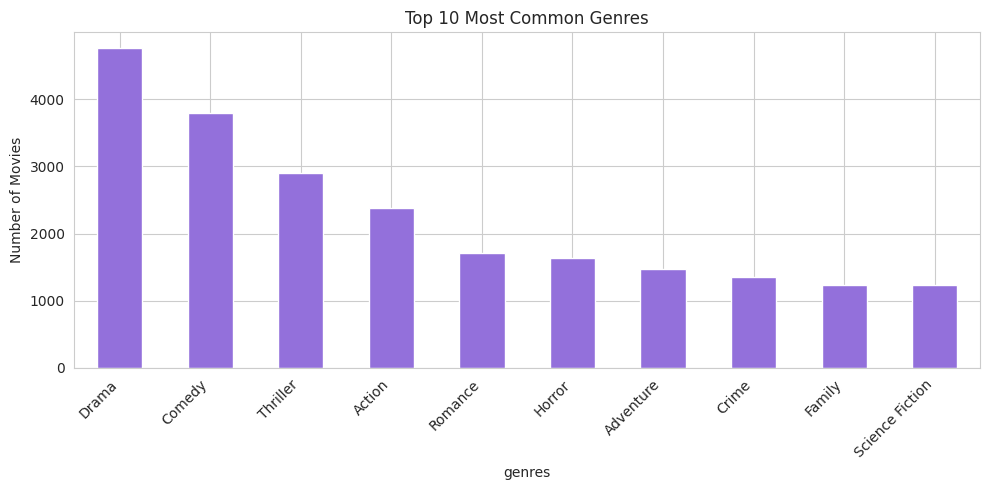

In [ ]:
genre_counts.plot(kind='bar', color='mediumpurple')
plt.ylabel('Number of Movies')
plt.title('Top 10 Most Common Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q6: Which genres bring in the most average revenue?

In [ ]:
genre_money = genres_df[['id', 'genres']].merge(money_df[['id', 'revenue', 'profit']], on='id')
genre_avg_revenue = genre_money.groupby('genres')['revenue'].mean().sort_values(ascending=False).head(10)
genre_avg_revenue

genres
Animation          2.571215e+08
Adventure          2.182919e+08
Fantasy            2.182341e+08
Family             2.031535e+08
Science Fiction    1.639331e+08
Action             1.565772e+08
War                1.060321e+08
Thriller           9.774046e+07
Comedy             9.733657e+07
Mystery            9.104578e+07
Name: revenue, dtype: float64

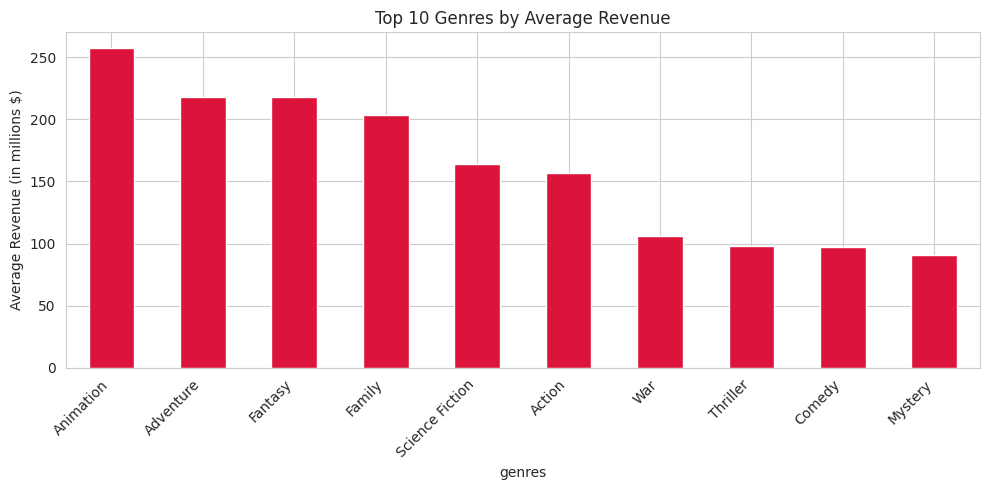

In [ ]:
(genre_avg_revenue / 1e6).plot(kind='bar', color='crimson')
plt.ylabel('Average Revenue (in millions $)')
plt.title('Top 10 Genres by Average Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q7: How has the number of movies released changed over the years?

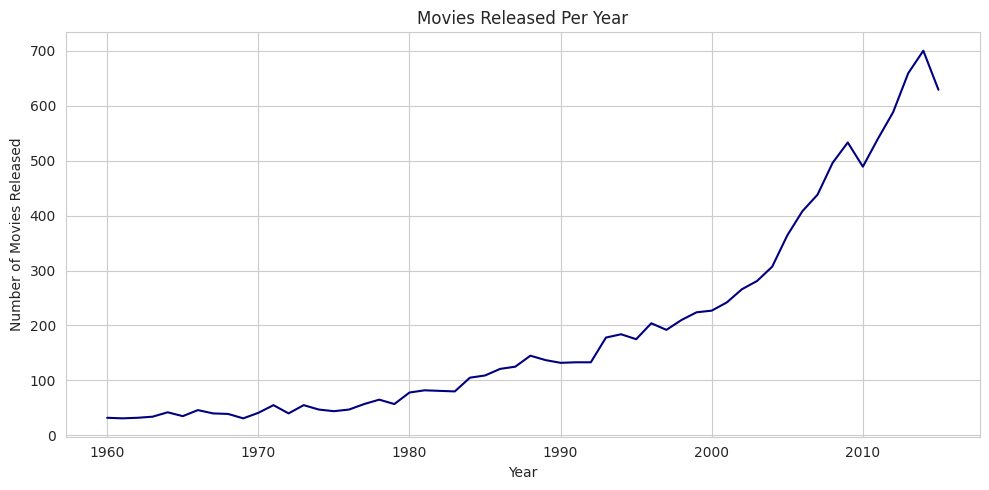

In [ ]:
movies_per_year = df['release_year'].value_counts().sort_index()

plt.plot(movies_per_year.index, movies_per_year.values, color='navy')
plt.xlabel('Year')
plt.ylabel('Number of Movies Released')
plt.title('Movies Released Per Year')
plt.tight_layout()
plt.show()

### Q8: Which directors have the most movies in this dataset?

In [ ]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
top_directors

director
Woody Allen          45
Clint Eastwood       34
Steven Spielberg     29
Martin Scorsese      29
Ridley Scott         23
Ron Howard           22
Steven Soderbergh    22
Joel Schumacher      21
Brian De Palma       20
Barry Levinson       19
Name: count, dtype: int64

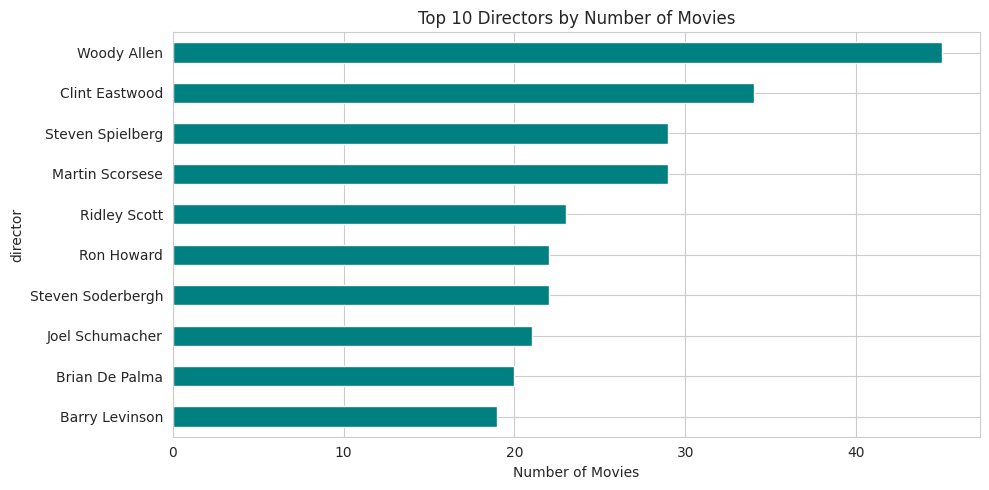

In [ ]:
top_directors.plot(kind='barh', color='teal')
plt.xlabel('Number of Movies')
plt.title('Top 10 Directors by Number of Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q9: What's the typical movie runtime?

count    10865.000000
mean       102.071790
std         31.382701
min          0.000000
25%         90.000000
50%         99.000000
75%        111.000000
max        900.000000
Name: runtime, dtype: float64


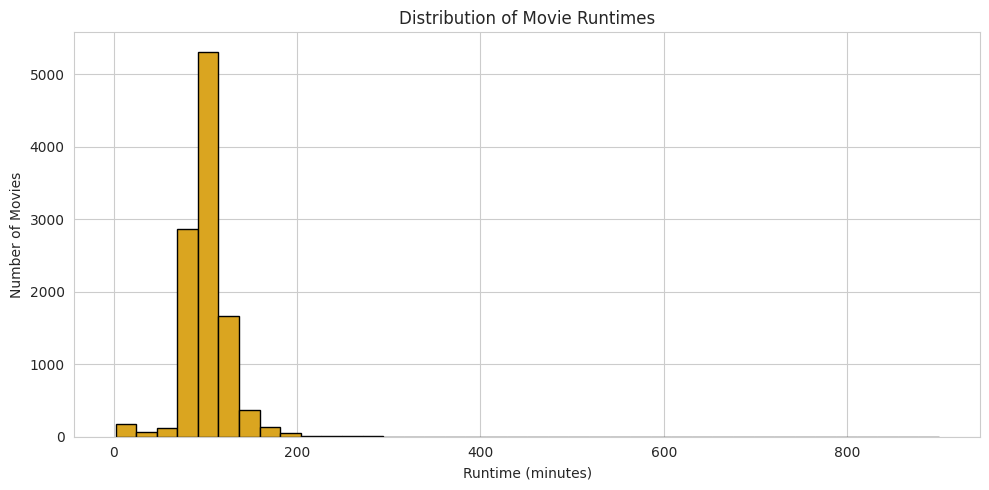

In [ ]:
print(df['runtime'].describe())

plt.hist(df[df['runtime'] > 0]['runtime'], bins=40, color='goldenrod', edgecolor='black')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.title('Distribution of Movie Runtimes')
plt.tight_layout()
plt.show()

### Q10: Is a movie's popularity related to how well it's rated (vote average)?

Correlation between popularity and vote average: 0.21


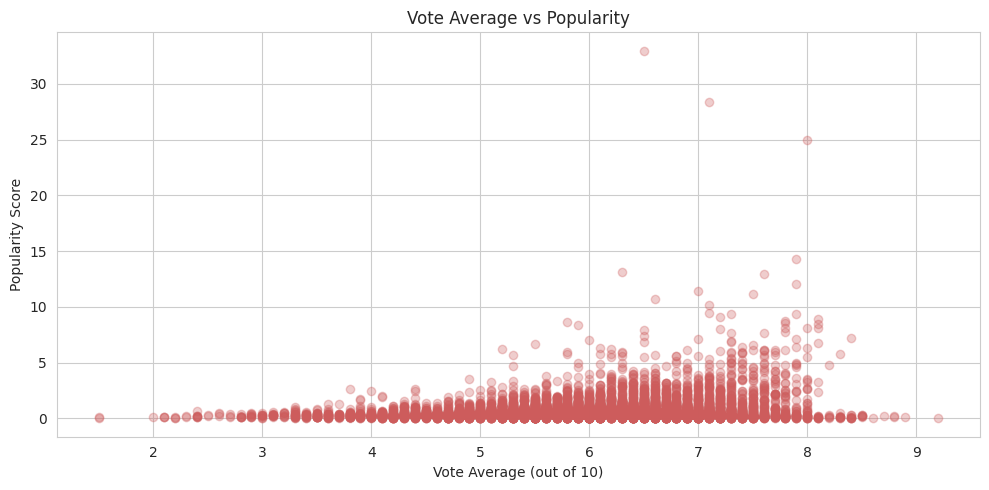

In [ ]:
correlation_pop_vote = df['popularity'].corr(df['vote_average'])
print(f"Correlation between popularity and vote average: {correlation_pop_vote:.2f}")

plt.scatter(df['vote_average'], df['popularity'], alpha=0.3, color='indianred')
plt.xlabel('Vote Average (out of 10)')
plt.ylabel('Popularity Score')
plt.title('Vote Average vs Popularity')
plt.tight_layout()
plt.show()

## 5. Summary of Findings

- A small number of blockbuster movies dominate popularity and revenue charts.
- Budget and revenue have some positive correlation, but a bigger budget doesn't guarantee bigger revenue — plenty of low-budget movies outperform expensive ones.
- **Drama**, **Comedy**, and **Thriller** tend to be among the most common genres, while genres like **Animation** and **Adventure** often earn the highest average revenue.
- The number of movies released per year generally increases over time, reflecting the growth of the film industry.
- A handful of directors appear repeatedly, suggesting a small group of prolific filmmakers.
- Most movies run between roughly 90–120 minutes.
- Popularity and audience rating (vote average) have only a weak relationship — a highly-rated movie isn't necessarily a popular one, and vice versa.

